In [2]:
#####################################################
# Imports and Files IO
#####################################################

import pandas as pd
import os
import numpy as np 
import glob
from MDToolkit.math.smoothing import lowess, savgol, convolve, kernel_nadaraya_watson 
from MDToolkit.math.differentiate import forward_finite_difference

frequency = 50 # MHz

files_dir = f"/media/jrjoseph/Elements/projects/fem_memristor/md_simulations/cscl_graphene_{frequency}MHz_ls6/"
ensembles = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# times = ["15ns", "20ns", "25ns", "30ns", "35ns"]

# df_list = []

# for time in times:
#     file_names = [f"kcl_mos2_ensemble{ensemble}_{time}.csv" for ensemble in ensembles]

#     dfs = [pd.read_csv(os.path.join(files_dir, file_name)) for file_name in file_names]

#     df = pd.concat(dfs).groupby(level=0).mean()

#     df_list.append(df)

# print(df_list[-1])

# Multiple CSV Files

csv_files = glob.glob(f"{files_dir}/*.csv")
df_list = [pd.read_csv(file) for file in csv_files]

In [3]:
# Manually Defined Electric Field
V_max = 1.2 # V/nm
period = 1 / (frequency * 10**6)
dt = 1 * 10 **-15 # 1 fs
V = V_max * np.sin(2*np.pi*df_list[0]["timesteps"] * dt / period)

def V_from_t(t_array, V_max, period, dt = 1 * 10**-15):
    return(V_max * np.sin(2*np.pi*t_array * dt / period))

In [4]:
#####################################################
# Plotting Functions
#####################################################
import matplotlib.pyplot as plt

def plot_IV_curve(V, I, xlabel = "Applied Electric Field (V/Å)", ylabel = "Ionic Current (arb. units)", ax = None):
    plt.plot(
        V,
        I,
        linewidth=1.5,
        label="Ionic current"
    )

    # Zero reference lines
    plt.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()

def plot_multiple_IV_curves(Vs, Is, xlabel = "Applied Electric Field (V/Å)", ylabel = "Ionic Current (nA)", legends: list = None):
    for i in range(len(Vs)):
        if legends is None:
            label = str(i+1)
        else:
            label = legends[i]
        plt.plot(Vs[i], Is[i], linewidth = 1.5, label=label)

    # Zero reference lines
    plt.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()


def plot_charge_translocations(t, translocations, xlabel = "Time (fs)", ylabel = "Charge Translocations (#)", ax = None):
    plt.scatter(t, translocations)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.show()

# def plot_charge_translocation_wfit(t, translocations, fit_translocations, xlabel = "Time (fs)", ylabel = "Charge Translocations (#)", ax = None, plot_raw_every_n = 100):
#     plt.scatter(t[::plot_raw_every_n], translocations[::plot_raw_every_n], label = "raw", color = "red")
#     plt.plot(t, fit_translocations, label = "fitted")
#     plt.xlabel(xlabel)
#     plt.ylabel(ylabel)

#     plt.legend()

#     plt.show()

def plot_charge_translocation_wfit(dfs, times, fit_translocations, xlabel = "Time (fs)", ylabel = "Charge Translocations (#)", plot_raw_every_n = 100):
    ncols = 2
    nrows = int(np.ceil(len(dfs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize = (7 * ncols, 4.5 * nrows))

    axes = np.atleast_1d(axes).flatten()

    for i, df in enumerate(dfs):
        t = df["timesteps"]
        translocations = df["cumulative_charge_translocation"]

        axes[i].scatter(t[::plot_raw_every_n], translocations[::plot_raw_every_n], label = "raw", color = "red")
        axes[i].plot(times[i], fit_translocations[i], label = "fitted")
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)

        axes[i].legend()

    # Hide unused axes if there is an odd number of datasets
    for i in range(len(dfs), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_ion_translocations(translocations_df_list: list[pd.DataFrame], xlabel = "Time (fs)", ylabel = "Ion Translocations (#)", cmap = "tab10", ax = None):
    cmap = plt.colormaps[cmap]

    colors = cmap(np.linspace(0, 1, len(translocations_df_list)))

    for j in range(len(translocations_df_list)):
        symbs = ["s", "*"]
        plotting_columns = translocations_df_list[j].columns[-2:]
        master_label = "".join([col.split("_")[-1] for col in plotting_columns])
        for i in range(len(plotting_columns)):
            running_sum = np.cumsum(translocations_df_list[j][plotting_columns[i]])
            plt.plot(translocations_df_list[j].iloc[:, 0], running_sum, label = f'{plotting_columns[i].split("_")[-1]}-{master_label}', marker = symbs[i], markevery=500, color = colors[j])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()


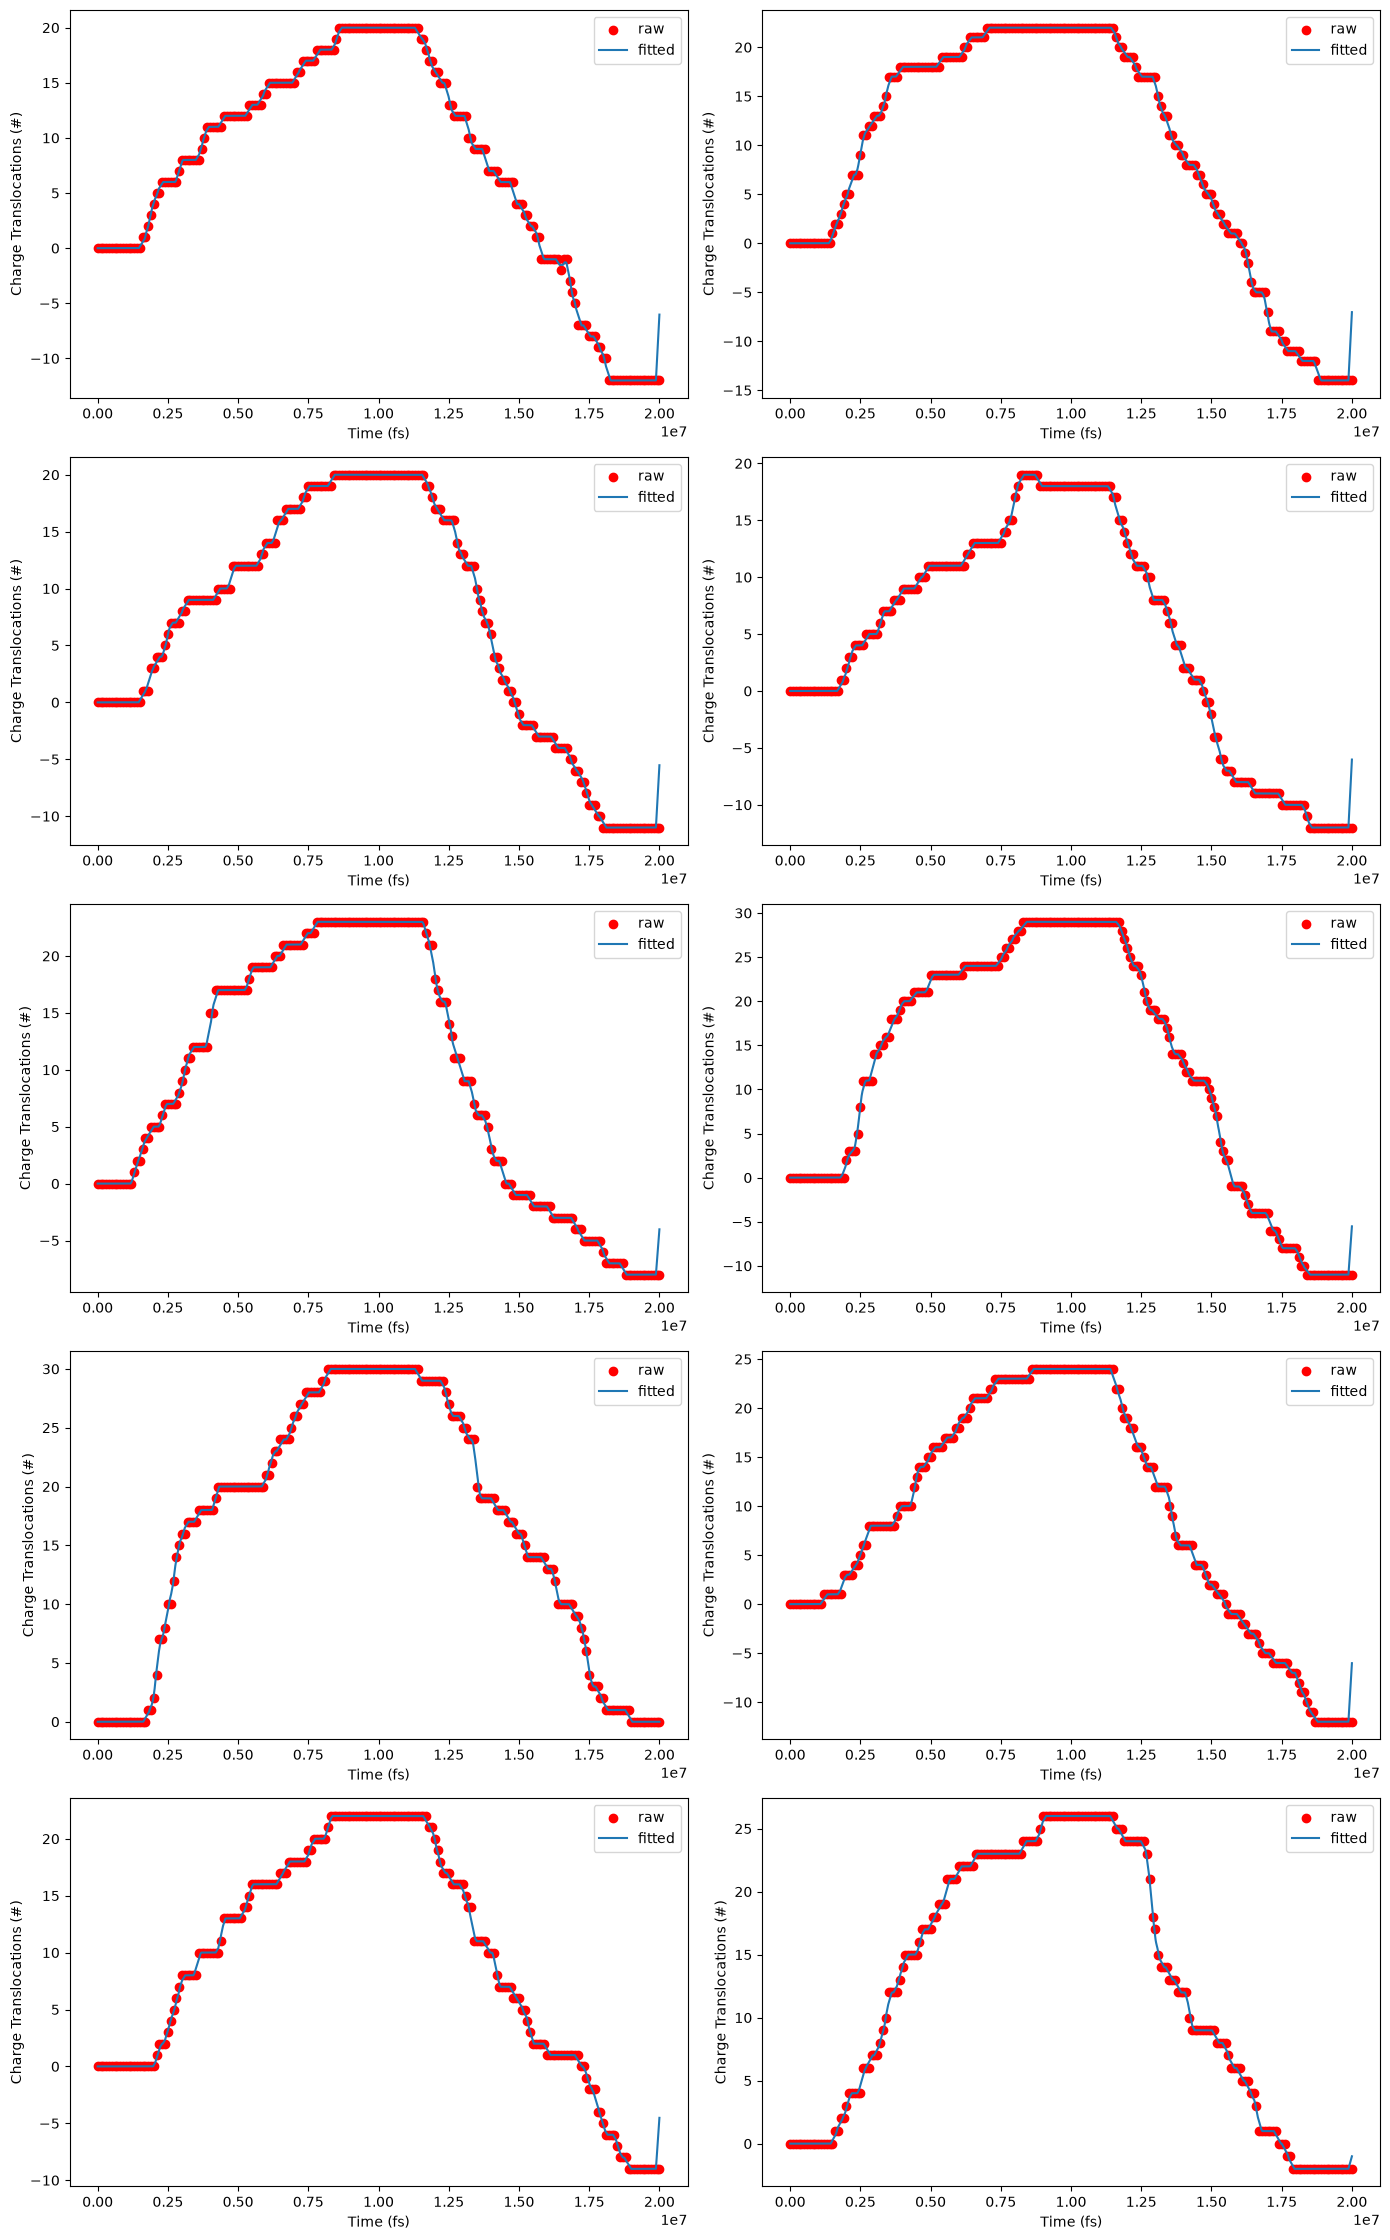

In [5]:
xs = []
ys = []
dydxs = []

per_period_window = 250
n_points = 100000

# int(per_period_window / ((max(df["timesteps"]) * 10**-15) / period))

for df in df_list:
    # x, y = lowess(df["timesteps"], df["cumulative_charge_translocation"], window = per_period_window, n_points=n_points)
    # x, y = savgol(df["timesteps"], df["cumulative_charge_translocation"], window = per_period_window, n_points=n_points)
    x, y = convolve(df["timesteps"], df["cumulative_charge_translocation"], window = per_period_window, n_points=n_points)
    xs.append(x)
    ys.append(y)
    dydxs.append(forward_finite_difference(x, y))

plot_charge_translocation_wfit(df_list, xs, ys)

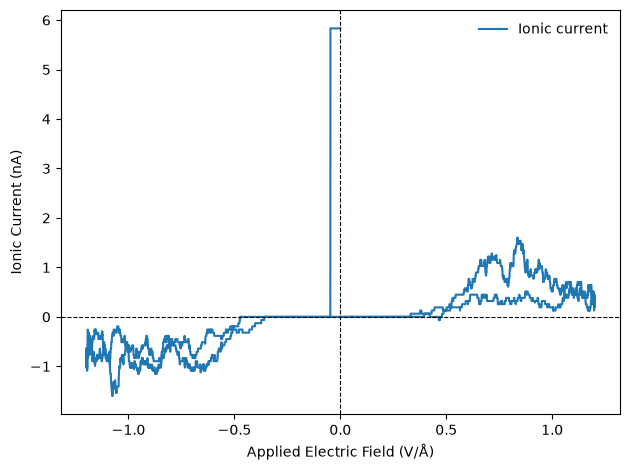

In [6]:
import scipy.constants as scc

I = np.mean(dydxs, axis = 0)
V = V_from_t(xs[0], V_max, period)

plot_IV_curve(V, I * scc.e * 10**15 * 10**9, ylabel="Ionic Current (nA)")

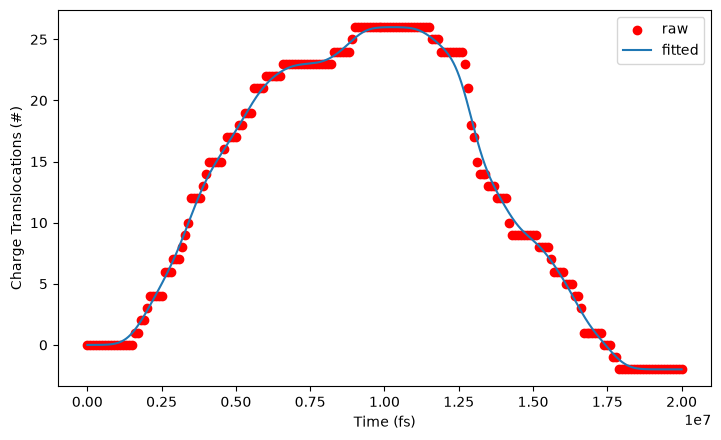

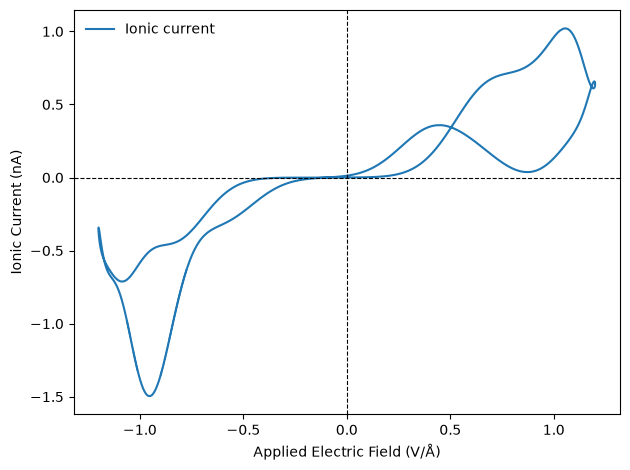

In [17]:
mean_df = pd.concat(df_list)
mean_df = df.groupby(df.index).mean()

# bandwidths = np.linspace(1000, 10000, 50)

mean_x, mean_y = kernel_nadaraya_watson(
    mean_df["timesteps"],
    mean_df["cumulative_charge_translocation"],
    bandwidth = 425000,
    n_points = n_points,
)

plot_charge_translocation_wfit([mean_df], [mean_x], [mean_y])

V_mean = V_from_t(mean_x, V_max, period)

plot_IV_curve(
    V_mean,
    forward_finite_difference(mean_x, mean_y) * scc.e * 10**15 * 10**9,
    ylabel = "Ionic Current (nA)",
)